In [ ]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from getdist import plots, loadMCSamples

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# ============================================================
# 1. CONFIGURACIÓN GRÁFICA
# ============================================================

font = {
    'size': 15,
    'family': 'sans-serif'
}

matplotlib.rc('font', **font)
plt.rcParams["text.usetex"] = False

# Compatibilidad con algunas versiones/código antiguo
np.infty = np.inf


# ============================================================
# 2. DIRECTORIO DE LAS CADENAS
# ============================================================

root_path = '/home/holman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/'

chain_root = os.path.join(
    root_path,
    'chains/wCDM/planck_hiig_cepheids'
)


# ============================================================
# 3. CARGAR CADENA
# ============================================================

samples = loadMCSamples(
    chain_root,
    settings={
        'ignore_rows': 0.3,
        'smooth_scale_1D': 0.6,
        'smooth_scale_2D': 0.6
    },
    no_cache=True
)

params = samples.getParams()


# ============================================================
# 4. VER QUÉ PARÁMETROS EXISTEN
# ============================================================

print("\nParámetros disponibles:\n")

for p in samples.getParamNames().names:
    print(p.name, "   ", p.label)

/home/holman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/wCDM/planck_hiig_cepheids.1.txt
/home/holman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/wCDM/planck_hiig_cepheids.2.txt
/home/holman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/wCDM/planck_hiig_cepheids.3.txt
/home/holman/HIIGalaxies/Bayesian_samplers/Cobaya/Lsigma/cobaya_lsigma_package/chains/wCDM/planck_hiig_cepheids.4.txt
Removed 0.3 as burn in

Parámetros disponibles:

logA     \log(10^{10}A_s)
n_s     n_s
omega_b     \Omega_b h^2
tau_reio     \tau_{\rm reio}
alpha_ls     \alpha_{L\sigma}
beta_ls     \beta_{L\sigma}
H0     H_0
Omega_m     \Omega_m
w0_fld     w_{\rm DE}
A_planck     y_\mathrm{cal}
A_s     A_s
chi2__CMB     \chi^2_\mathrm{CMB}
minuslogprior     -\log\pi
minuslogprior__0     -\log\pi_\mathrm{0}
chi2     \chi^2
chi2__planck_2018_lowl.TT     \chi^2_\mathrm{planck\ 2018\ lowl.TT}
chi2__planck_2018_lowl.EE     \chi^2_\mathrm{plan

In [ ]:
# ============================================================
# 5. PARÁMETROS DERIVADOS
# ============================================================

samples.addDerived(
    params.H0 / 100.0,
    name='h',
    label='h'
)

q0 = (
    0.5 * params.Omega_m
    + 0.5 * (1.0 + 3.0 * params.w0_fld)
    * (1.0 - params.Omega_m)
)

samples.addDerived(
    q0,
    name='q0',
    label='q_0'
)



In [ ]:
# ============================================================
# 6. TABLA DE RESULTADOS
# ============================================================

main_params = [
    'H0',
    'Omega_m',
    'w0_fld',
    'alpha_ls',
    'beta_ls'
]

print(
    samples.getTable(
        limit=1,
        paramList=main_params
    ).tableTex()
)

\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldmath$\alpha_{L\sigma}$} & $33.102\pm 0.071           $\\

{\boldmath$\beta_{L\sigma}$} & $5.119\pm 0.047            $\\

{\boldmath$H_0            $} & $72.4\pm 2.0               $\\

{\boldmath$\Omega_m       $} & $0.273\pm 0.015            $\\

{\boldmath$w_{\rm DE}     $} & $-1.159\pm 0.065           $\\
\hline
\end{tabular}


In [ ]:
print(
    samples.getTable(
        limit=2,
        paramList=main_params
    ).tableTex()
)

\begin{tabular} { l  c}

 Parameter &  95\% limits\\
\hline
{\boldmath$\alpha_{L\sigma}$} & $33.10^{+0.14}_{-0.14}     $\\

{\boldmath$\beta_{L\sigma}$} & $5.119^{+0.095}_{-0.092}   $\\

{\boldmath$H_0            $} & $72.4^{+4.0}_{-3.8}        $\\

{\boldmath$\Omega_m       $} & $0.273^{+0.031}_{-0.029}   $\\

{\boldmath$w_{\rm DE}     $} & $-1.16^{+0.12}_{-0.13}     $\\
\hline
\end{tabular}


In [ ]:
# ============================================================
# 7. LIKELIHOOD STATISTICS
# ============================================================

print(samples.getLikeStats())

Best fit sample -log(Like) = 971.187260
Ln(mean 1/like) = 980.299515
mean(-Ln(like)) = 975.904161
-Ln(mean like)  = 974.344046
2*Var(Ln(like)) = 9.992736

parameter                                         bestfit        lower1         upper1         lower2         upper2
logA                                              3.0391211E+00  2.9983731E+00  3.0859722E+00  2.9875447E+00  3.0945069E+00   \log(10^{10}A_s)
n_s                                               9.6559991E-01  9.5436060E-01  9.7753341E-01  9.5085327E-01  9.7960103E-01   n_s
omega_b                                           2.2291815E-02  2.1953546E-02  2.2801581E-02  2.1883546E-02  2.2897573E-02   \Omega_b h^2
tau_reio                                          5.2879054E-02  3.2455676E-02  7.7541161E-02  2.4112149E-02  8.0110488E-02   \tau_{\rm reio}
alpha_ls                                          3.3102134E+01  3.2880301E+01  3.3307977E+01  3.2845192E+01  3.3337486E+01   \alpha_{L\sigma}
beta_ls                        

In [ ]:
# ============================================================
# 7. LIKELIHOOD STATISTICS
# ============================================================

print(samples.getLikeStats())

Best fit sample -log(Like) = 971.187260
Ln(mean 1/like) = 980.299515
mean(-Ln(like)) = 975.904161
-Ln(mean like)  = 974.344046
2*Var(Ln(like)) = 9.992736

parameter                                         bestfit        lower1         upper1         lower2         upper2
logA                                              3.0391211E+00  2.9983731E+00  3.0859722E+00  2.9875447E+00  3.0945069E+00   \log(10^{10}A_s)
n_s                                               9.6559991E-01  9.5436060E-01  9.7753341E-01  9.5085327E-01  9.7960103E-01   n_s
omega_b                                           2.2291815E-02  2.1953546E-02  2.2801581E-02  2.1883546E-02  2.2897573E-02   \Omega_b h^2
tau_reio                                          5.2879054E-02  3.2455676E-02  7.7541161E-02  2.4112149E-02  8.0110488E-02   \tau_{\rm reio}
alpha_ls                                          3.3102134E+01  3.2880301E+01  3.3307977E+01  3.2845192E+01  3.3337486E+01   \alpha_{L\sigma}
beta_ls                        

In [ ]:
stats = samples.getMargeStats()

for name in main_params:
    par = stats.parWithName(name)

    print(
        f"{name:10s} : "
        f"{par.mean:.5f} "
        f"+{par.limits[0].upper - par.mean:.5f} "
        f"{par.limits[0].lower - par.mean:.5f}"
    )

H0         : 72.40943 +1.95161 -2.11781
Omega_m    : 0.27270 +0.01559 -0.01582
w0_fld     : -1.15949 +0.06855 -0.06353
alpha_ls   : 33.10199 +0.07007 -0.07133
beta_ls    : 5.11897 +0.04709 -0.04637


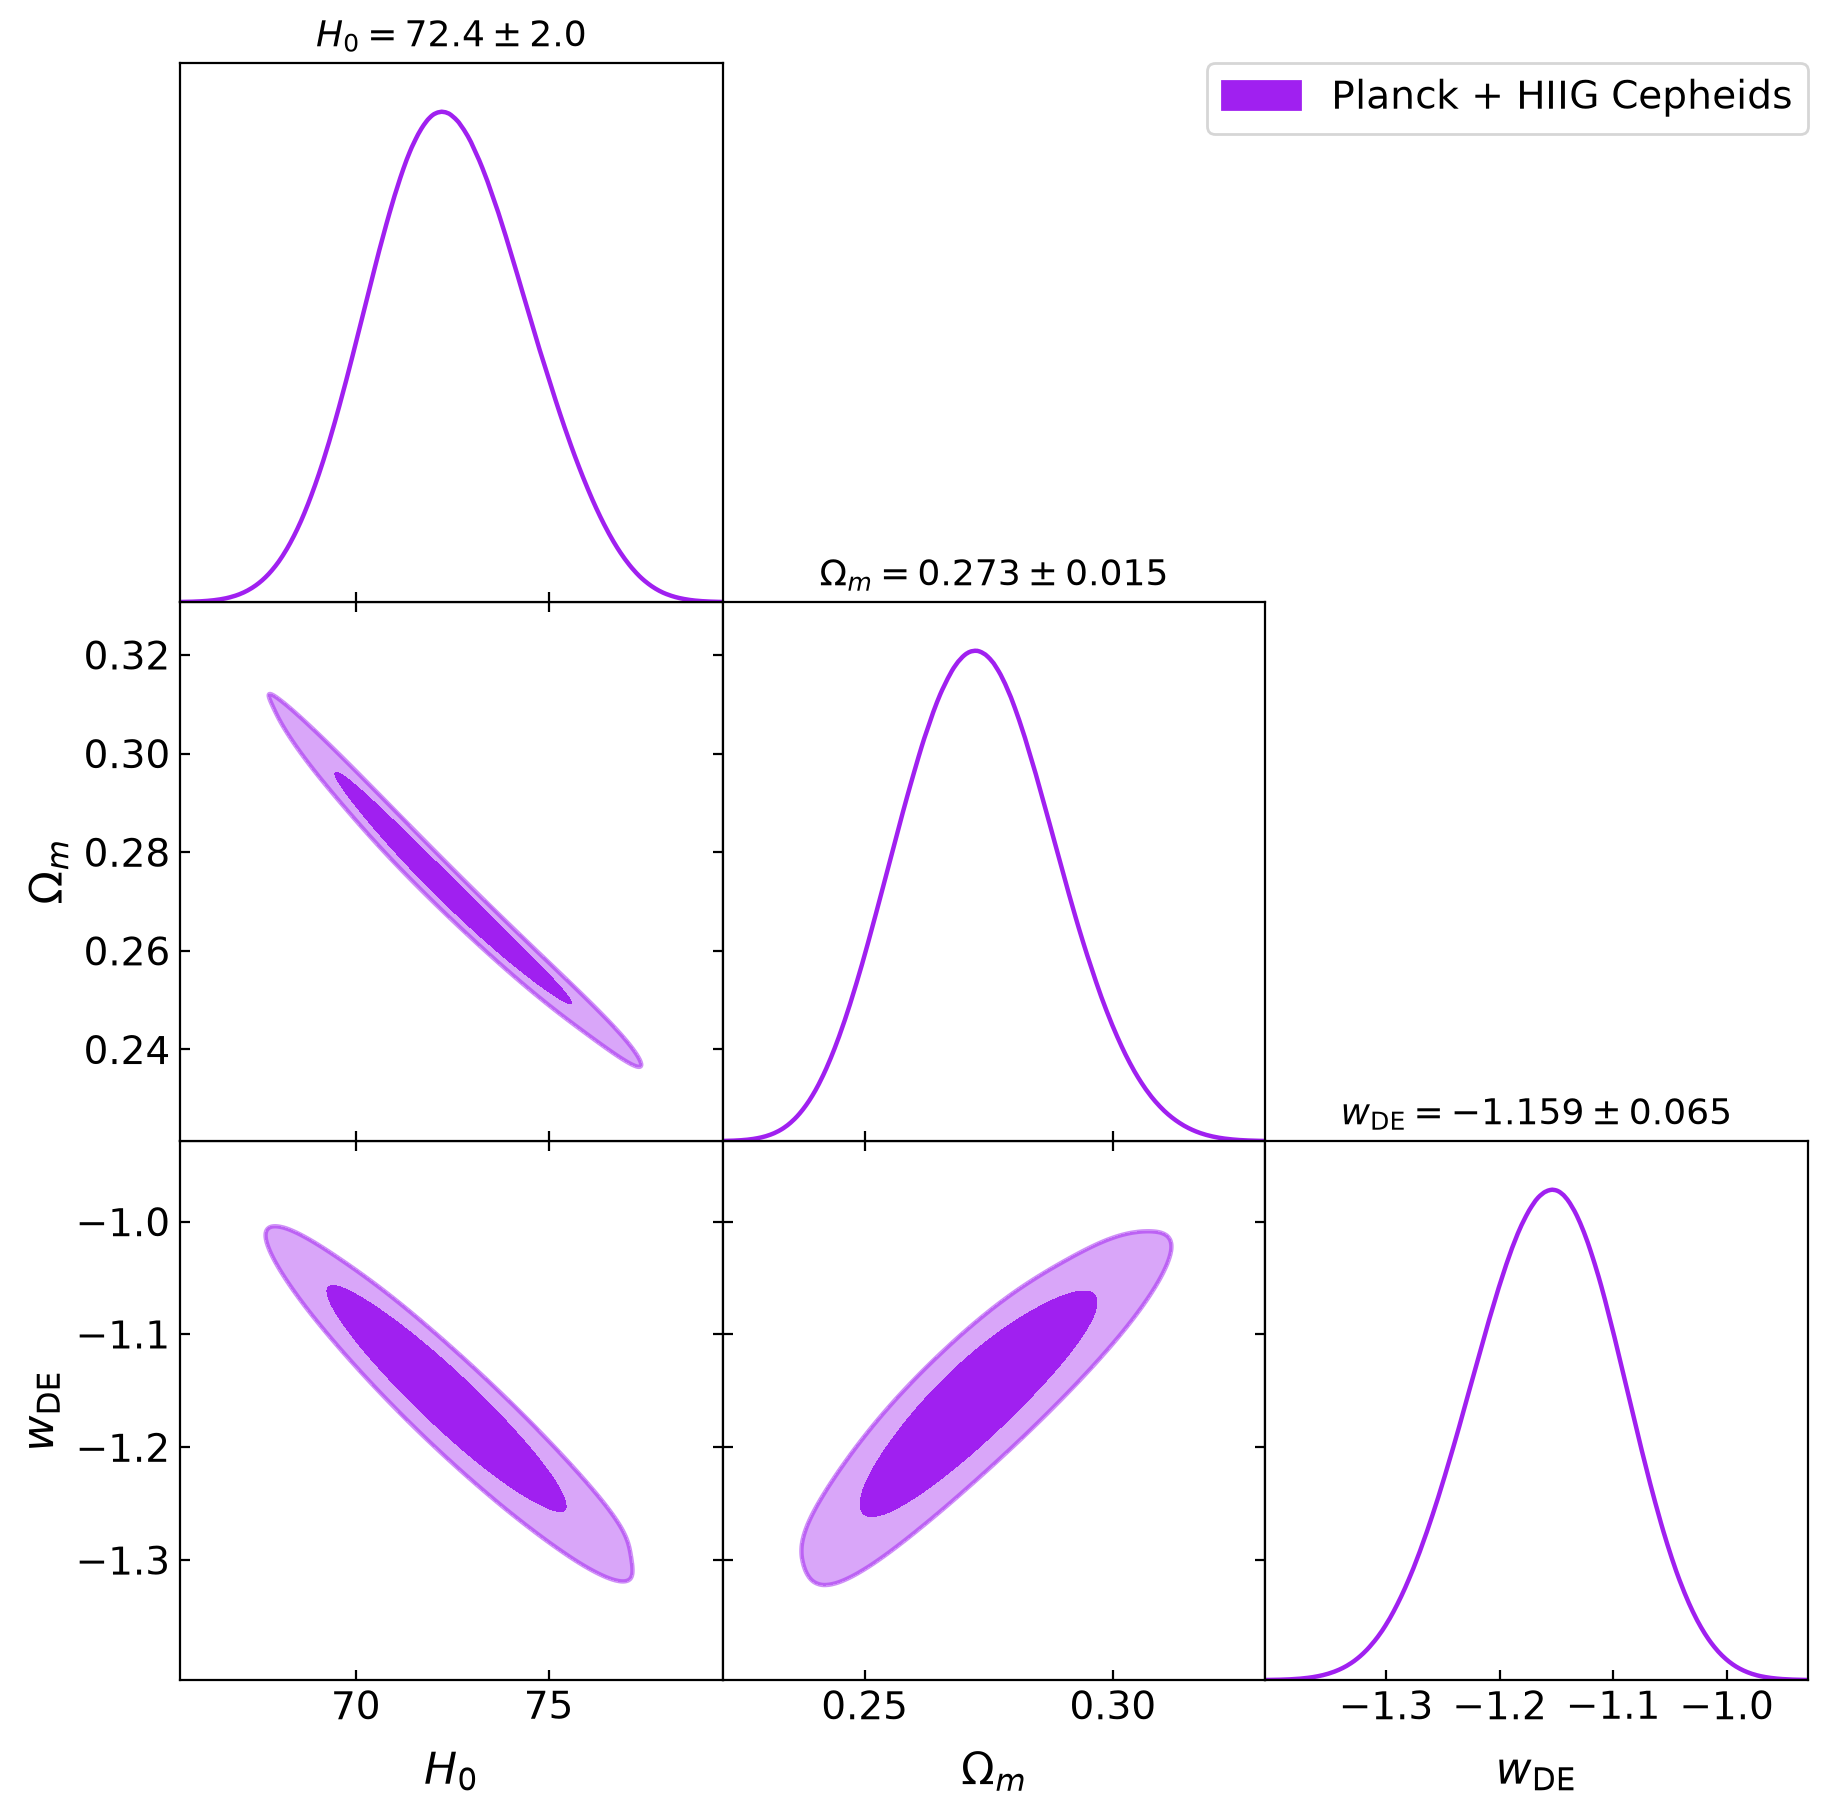

In [ ]:
# ============================================================
# 8. TRIANGLE PLOT COSMOLÓGICO
# ============================================================

g = plots.get_subplot_plotter(
    subplot_size=3.5
)

g.settings.axes_fontsize = 14
g.settings.lab_fontsize = 16
g.settings.legend_fontsize = 14
g.settings.title_limit_fontsize = 13

g.triangle_plot(
    [samples],
    ['H0', 'Omega_m', 'w0_fld'],
    filled=True,
    shaded=False,
    legend_labels=[
        r'Planck + HIIG Cepheids'
    ],
    contour_colors=[
        '#A020F0'
    ],
    contour_lws=1.6,
    title_limit=1
)

plt.savefig(
    'Planck_HIIG_Cepheids_wCDM_cosmology.pdf',
    bbox_inches='tight'
)

plt.show()

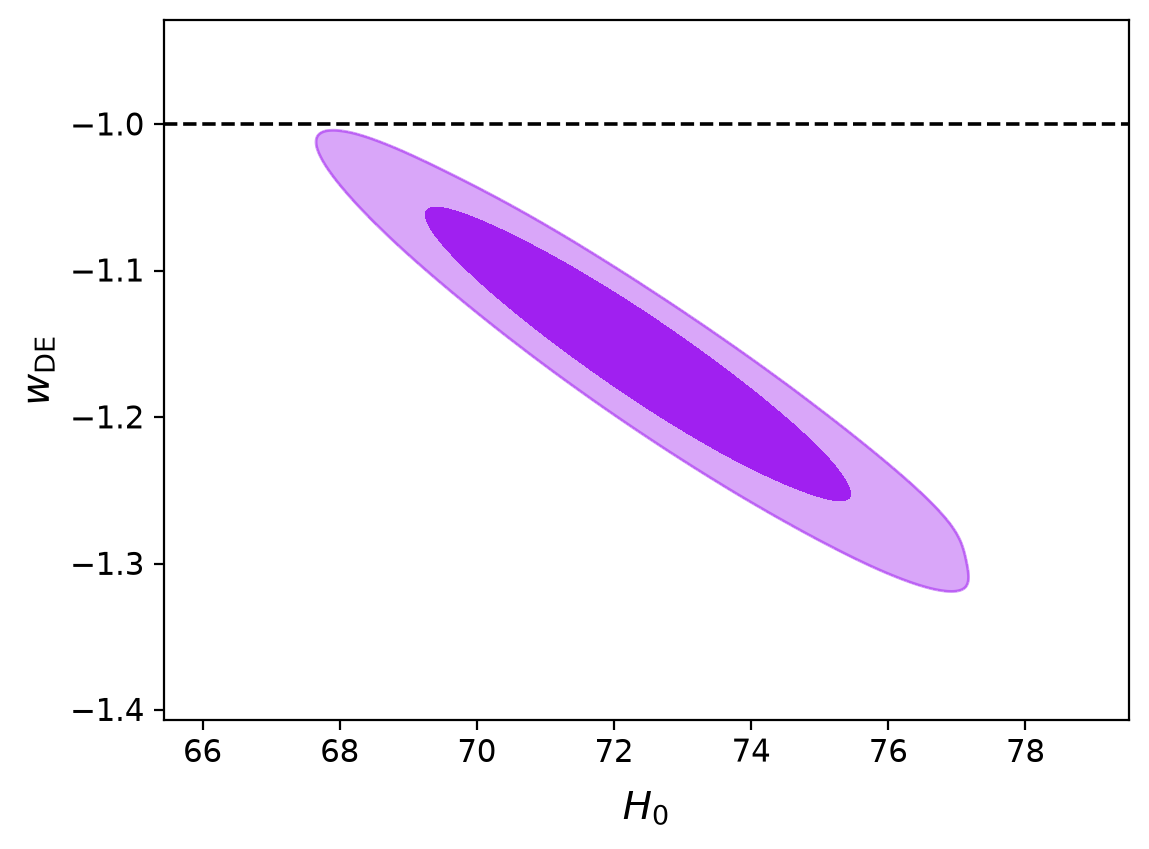

In [17]:
# ============================================================
# 13. DEGENERACIÓN H0 - w
# ============================================================

g = plots.get_single_plotter(
    width_inch=6
)

g.plot_2d(
    [samples],
    'H0',
    'w0_fld',
    filled=True,
    colors=['#A020F0']
)

plt.axhline(
    -1.0,
    color='black',
    linestyle='--',
    linewidth=1.3
)

plt.savefig(
    'Planck_HIIG_Cepheids_wCDM_H0_w.pdf',
    bbox_inches='tight'
)

plt.show()